## Imports

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Load Processed Data

In [3]:
# Load the cleaned dataset from previous notebook
df = pd.read_csv('../data/processed/cleaned_news_data.csv')

print(f"Dataset loaded: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nClass distribution:")
print(df['label'].value_counts())
print(f"\nFake: {len(df[df['label']==0])} | True: {len(df[df['label']==1])}")

df.head()

Dataset loaded: (43944, 7)
Columns: ['title', 'text', 'cleaned_title', 'cleaned_text', 'subject', 'date', 'label']

Class distribution:
label
0    22528
1    21416
Name: count, dtype: int64

Fake: 22528 | True: 21416


,title,text,cleaned_title,cleaned_text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,donald trump sends embarrassing new year ’ eve...,donald trump wish american happy new year leav...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,drunk bragging trump staffer started russian c...,house intelligence committee chairman devin nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",sheriff david clarke becomes internet joke thr...,friday revealed former milwaukee sheriff david...,News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",trump obsessed even obama ’ name coded website...,christmas day donald trump announced would bac...,News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,pope francis called donald trump christmas speech,pope francis used annual christmas day message...,News,"December 25, 2017",0


## Prepare Data for Training

In [4]:
# Use cleaned_text for training
X = df['cleaned_text']
y = df['label']

print(f"Features (X): {X.shape}")
print(f"Labels (y): {y.shape}")
print(f"\nSample text:")
print(X.iloc[0][:200])
print(f"\nLabel: {y.iloc[0]} ({'True' if y.iloc[0]==1 else 'Fake'})")

Features (X): (43944,)
Labels (y): (43944,)

Sample text:
donald trump wish american happy new year leave instead give shout enemy hater dishonest fake news medium former reality show star one job country rapidly grows stronger smarter want wish friend suppo

Label: 0 (Fake)


## Train-Test Split

In [5]:
# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("="*60)
print("DATA SPLIT")
print("="*60)
print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"\nTraining set distribution:")
print(y_train.value_counts())
print(f"\nTest set distribution:")
print(y_test.value_counts())

DATA SPLIT
Training set: 35155 samples
Test set: 8789 samples

Training set distribution:
label
0    18022
1    17133
Name: count, dtype: int64

Test set distribution:
label
0    4506
1    4283
Name: count, dtype: int64


## TF-IDF Vectorization

In [6]:
print("Creating TF-IDF vectors...")
print("This may take 2-3 minutes...")

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,      # Limit to top 5000 words
    ngram_range=(1, 2),     # Use unigrams and bigrams
    min_df=5,               # Word must appear in at least 5 documents
    max_df=0.8              # Ignore words that appear in >80% of documents
)

# Fit and transform training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform test data (don't fit!)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"✅ Vectorization complete!")
print(f"\nTF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test): {X_test_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")

Creating TF-IDF vectors...
This may take 2-3 minutes...
✅ Vectorization complete!

TF-IDF matrix shape (train): (35155, 5000)
TF-IDF matrix shape (test): (8789, 5000)
Vocabulary size: 5000


## Train Logistics Regression Model

In [7]:
print("Training Logistic Regression model...")
print("This may take 1-2 minutes...")

# Initialize and train model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1,              # Use all CPU cores
    solver='saga'           # Works well with large datasets
)

lr_model.fit(X_train_tfidf, y_train)

print("✅ Model training complete!")
print(f"\nModel coefficients shape: {lr_model.coef_.shape}")
print(f"Classes: {lr_model.classes_}")

Training Logistic Regression model...
This may take 1-2 minutes...
✅ Model training complete!

Model coefficients shape: (1, 5000)
Classes: [0 1]


## Make Predictions

In [8]:
# Predictions on test set
y_pred = lr_model.predict(X_test_tfidf)
y_pred_proba = lr_model.predict_proba(X_test_tfidf)

print("✅ Predictions complete!")
print(f"\nFirst 10 predictions:")
print(y_pred[:10])
print(f"\nFirst 10 actual labels:")
print(y_test.values[:10])
print(f"\nFirst 10 prediction probabilities:")
print(y_pred_proba[:10])

✅ Predictions complete!

First 10 predictions:
[1 1 0 0 0 1 1 1 1 0]

First 10 actual labels:
[1 1 1 0 0 1 1 1 1 0]

First 10 prediction probabilities:
[[3.53850738e-02 9.64614926e-01]
 [7.90903491e-03 9.92090965e-01]
 [9.95389037e-01 4.61096257e-03]
 [9.93398995e-01 6.60100504e-03]
 [9.80476361e-01 1.95236385e-02]
 [4.16781870e-04 9.99583218e-01]
 [7.50553837e-02 9.24944616e-01]
 [1.68363889e-02 9.83163611e-01]
 [1.48869882e-02 9.85113012e-01]
 [9.81418383e-01 1.85816175e-02]]


## Model Evaluation

In [9]:
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])

print("="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC AUC:   {roc_auc:.4f}")

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Fake', 'True']))

MODEL PERFORMANCE METRICS
Accuracy:  0.9884 (98.84%)
Precision: 0.9840
Recall:    0.9923
F1 Score:  0.9881
ROC AUC:   0.9986

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Fake       0.99      0.98      0.99      4506
        True       0.98      0.99      0.99      4283

    accuracy                           0.99      8789
   macro avg       0.99      0.99      0.99      8789
weighted avg       0.99      0.99      0.99      8789



## Confusion Matrix Visualization

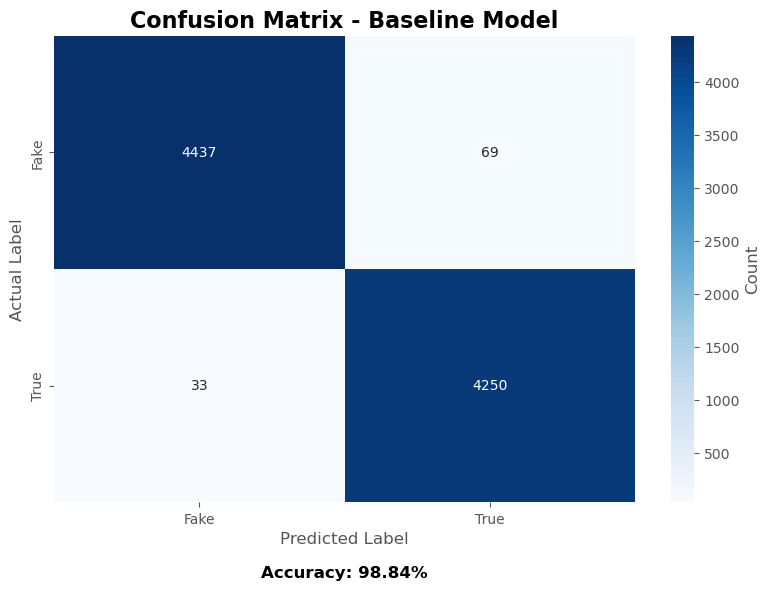


True Negatives (Correct Fake): 4437
False Positives (Fake predicted as True): 69
False Negatives (True predicted as Fake): 33
True Positives (Correct True): 4250


In [10]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fake', 'True'],
            yticklabels=['Fake', 'True'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Baseline Model', fontsize=16, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

# Add accuracy text
accuracy_text = f'Accuracy: {accuracy:.2%}'
plt.text(0.5, -0.15, accuracy_text, 
         ha='center', va='center', 
         transform=ax.transAxes,
         fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nTrue Negatives (Correct Fake): {cm[0,0]}")
print(f"False Positives (Fake predicted as True): {cm[0,1]}")
print(f"False Negatives (True predicted as Fake): {cm[1,0]}")
print(f"True Positives (Correct True): {cm[1,1]}")

## ROC Curve

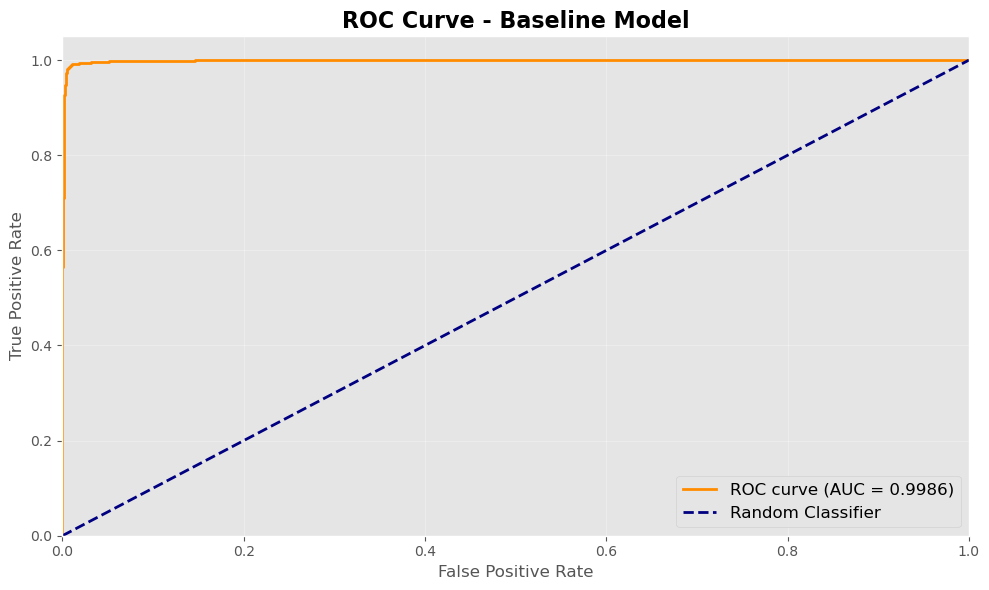

In [11]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Baseline Model', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Feature Importance - Top Predictive Words

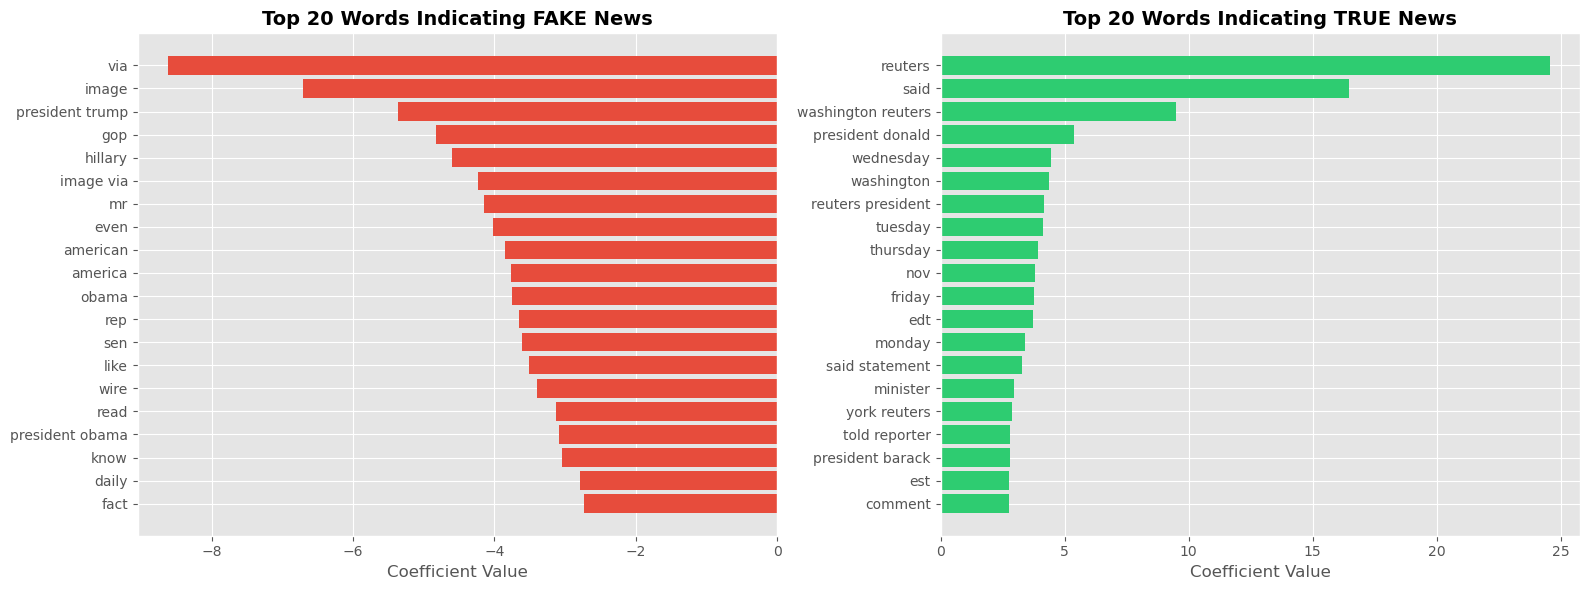

TOP PREDICTIVE WORDS

FAKE News Indicators:
  via: -8.6162
  image: -6.7064
  president trump: -5.3590
  gop: -4.8320
  hillary: -4.6008
  image via: -4.2293
  mr: -4.1469
  even: -4.0176
  american: -3.8496
  america: -3.7639
  obama: -3.7588
  rep: -3.6484
  sen: -3.6128
  like: -3.5168
  wire: -3.4050
  read: -3.1352
  president obama: -3.0937
  know: -3.0422
  daily: -2.7964
  fact: -2.7320

TRUE News Indicators:
  reuters: 24.5462
  said: 16.4735
  washington reuters: 9.5042
  president donald: 5.3811
  wednesday: 4.4609
  washington: 4.3874
  reuters president: 4.1590
  tuesday: 4.1327
  thursday: 3.9458
  nov: 3.8028
  friday: 3.7785
  edt: 3.7215
  monday: 3.4016
  said statement: 3.2715
  minister: 2.9626
  york reuters: 2.8843
  told reporter: 2.8137
  president barack: 2.7959
  est: 2.7638
  comment: 2.7421


In [12]:
# Get feature names and coefficients
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
coefficients = lr_model.coef_[0]

# Top words for FAKE news (negative coefficients)
top_fake_indices = coefficients.argsort()[:20]
top_fake_words = feature_names[top_fake_indices]
top_fake_coef = coefficients[top_fake_indices]

# Top words for TRUE news (positive coefficients)
top_true_indices = coefficients.argsort()[-20:][::-1]
top_true_words = feature_names[top_true_indices]
top_true_coef = coefficients[top_true_indices]

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fake news indicators
axes[0].barh(range(len(top_fake_words)), top_fake_coef, color='#e74c3c')
axes[0].set_yticks(range(len(top_fake_words)))
axes[0].set_yticklabels(top_fake_words)
axes[0].set_xlabel('Coefficient Value', fontsize=12)
axes[0].set_title('Top 20 Words Indicating FAKE News', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

# True news indicators
axes[1].barh(range(len(top_true_words)), top_true_coef, color='#2ecc71')
axes[1].set_yticks(range(len(top_true_words)))
axes[1].set_yticklabels(top_true_words)
axes[1].set_xlabel('Coefficient Value', fontsize=12)
axes[1].set_title('Top 20 Words Indicating TRUE News', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("="*60)
print("TOP PREDICTIVE WORDS")
print("="*60)
print("\nFAKE News Indicators:")
for word, coef in zip(top_fake_words, top_fake_coef):
    print(f"  {word}: {coef:.4f}")
    
print("\nTRUE News Indicators:")
for word, coef in zip(top_true_words, top_true_coef):
    print(f"  {word}: {coef:.4f}")

## Test on Sample Articles

In [13]:
# Function to predict on new text
def predict_article(text):
    """Predict if an article is fake or true"""
    # Preprocess (you'll need the same preprocessing function)
    from nltk.corpus import stopwords
    from nltk.tokenize import word_tokenize
    from nltk.stem import WordNetLemmatizer
    import re
    import string
    
    # Simple preprocessing
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    cleaned = ' '.join(tokens)
    
    # Vectorize
    text_tfidf = tfidf_vectorizer.transform([cleaned])
    
    # Predict
    prediction = lr_model.predict(text_tfidf)[0]
    probability = lr_model.predict_proba(text_tfidf)[0]
    
    return {
        'prediction': 'TRUE' if prediction == 1 else 'FAKE',
        'confidence': probability[prediction] * 100,
        'probabilities': {
            'fake': probability[0] * 100,
            'true': probability[1] * 100
        }
    }

# Test on a sample from test set
sample_idx = 0
sample_text = df.iloc[X_test.index[sample_idx]]['text']
sample_label = y_test.iloc[sample_idx]

result = predict_article(sample_text)

print("="*60)
print("SAMPLE PREDICTION")
print("="*60)
print(f"\nArticle (first 300 chars):")
print(sample_text[:300] + "...")
print(f"\nActual Label: {'TRUE' if sample_label==1 else 'FAKE'}")
print(f"\nPredicted: {result['prediction']}")
print(f"Confidence: {result['confidence']:.2f}%")
print(f"\nProbabilities:")
print(f"  Fake: {result['probabilities']['fake']:.2f}%")
print(f"  True: {result['probabilities']['true']:.2f}%")

SAMPLE PREDICTION

Article (first 300 chars):
WASHINGTON (Reuters) - Besieged by controversy at home, U.S. President Donald Trump is under pressure to stick to the script and avoid fresh flare-ups when he embarks this week on his first foreign trip, a nine-day trek to the Middle East and Europe. White House officials and Republicans close to th...

Actual Label: TRUE

Predicted: TRUE
Confidence: 96.46%

Probabilities:
  Fake: 3.54%
  True: 96.46%


## Save Model & Vectorizer

In [14]:
import os

# Create models directory
os.makedirs('../models', exist_ok=True)

# Save the model
model_path = '../models/baseline_lr_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(lr_model, f)

# Save the vectorizer
vectorizer_path = '../models/tfidf_vectorizer.pkl'
with open(vectorizer_path, 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

print(f"✅ Model saved to: {model_path}")
print(f"✅ Vectorizer saved to: {vectorizer_path}")

# Check file sizes
model_size = os.path.getsize(model_path) / (1024 * 1024)  # MB
vectorizer_size = os.path.getsize(vectorizer_path) / (1024 * 1024)  # MB

print(f"\nModel size: {model_size:.2f} MB")
print(f"Vectorizer size: {vectorizer_size:.2f} MB")
print(f"Total size: {model_size + vectorizer_size:.2f} MB")

✅ Model saved to: ../models/baseline_lr_model.pkl
✅ Vectorizer saved to: ../models/tfidf_vectorizer.pkl

Model size: 0.04 MB
Vectorizer size: 0.18 MB
Total size: 0.22 MB


## Model Summary

In [15]:
print("="*60)
print("BASELINE MODEL SUMMARY")
print("="*60)
print(f"\nModel: Logistic Regression with TF-IDF")
print(f"Vocabulary Size: {len(tfidf_vectorizer.vocabulary_)}")
print(f"Max Features: 5000")
print(f"N-gram Range: (1, 2)")

print(f"\nTraining Set: {len(X_train)} samples")
print(f"Test Set: {len(X_test)} samples")

print(f"\n📊 PERFORMANCE:")
print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print(f"  ROC AUC:   {roc_auc:.4f}")

print(f"\n💾 MODEL SIZE: {model_size + vectorizer_size:.2f} MB")

print("\n✅ Baseline model training complete!")
print("🎯 Ready to train DistilBERT model next!")

BASELINE MODEL SUMMARY

Model: Logistic Regression with TF-IDF
Vocabulary Size: 5000
Max Features: 5000
N-gram Range: (1, 2)

Training Set: 35155 samples
Test Set: 8789 samples

📊 PERFORMANCE:
  Accuracy:  0.9884 (98.84%)
  Precision: 0.9840
  Recall:    0.9923
  F1 Score:  0.9881
  ROC AUC:   0.9986

💾 MODEL SIZE: 0.22 MB

✅ Baseline model training complete!
🎯 Ready to train DistilBERT model next!
